<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter9_StableDiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text-to-Image Generation with Stable Diffusion

In [1]:
# Stable Diffusion v1.5
!pip install diffusers transformers accelerate safetensors sympy
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32
).to(device)

pipe.safety_checker = lambda images, **kwargs: (images, [False] * len(images))
# 실습 편의를 위한 safety checker 비활성화

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

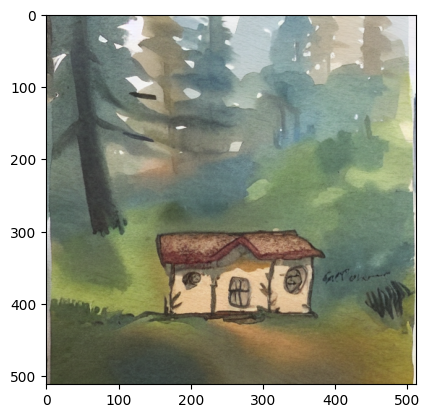

In [3]:
# Basic Text-to-Image generation

prompt = "a watercolor painting of a small cottage in a quiet forest"
image = pipe(prompt).images
plt.imshow(image[0])

  0%|          | 0/50 [00:00<?, ?it/s]

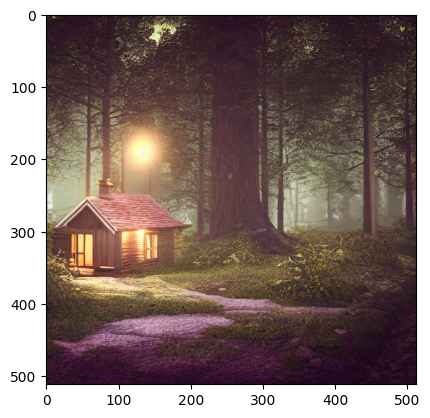

In [4]:
# style change
prompt = "a small cottage in a quiet forest, cinematic lighting, 3d rendering"
image = pipe(prompt).images
plt.imshow(image[0])

  0%|          | 0/50 [00:00<?, ?it/s]

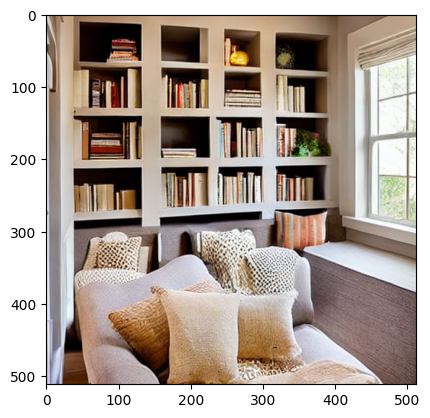

In [6]:
# negative prompt
prompt = "a cozy reading room with warm lighting"
negative = "blurry, distorted, low quality"

image = pipe(prompt, negative_prompt=negative).images
plt.imshow(image[0])

  0%|          | 0/50 [00:00<?, ?it/s]

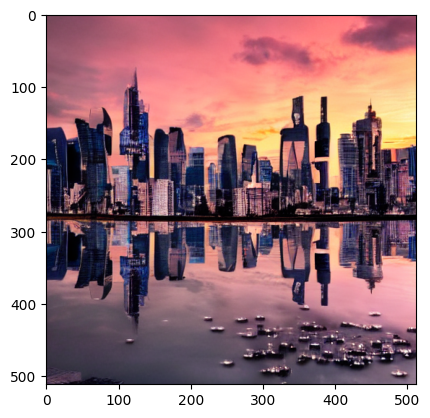

In [7]:
# Image size , random seed
generator = torch.Generator(device).manual_seed(0)

image = pipe("a futuristic city skyline at sunset",
             height=512,
             width=512,
             generator=generator
             ).images

plt.imshow(image[0])

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

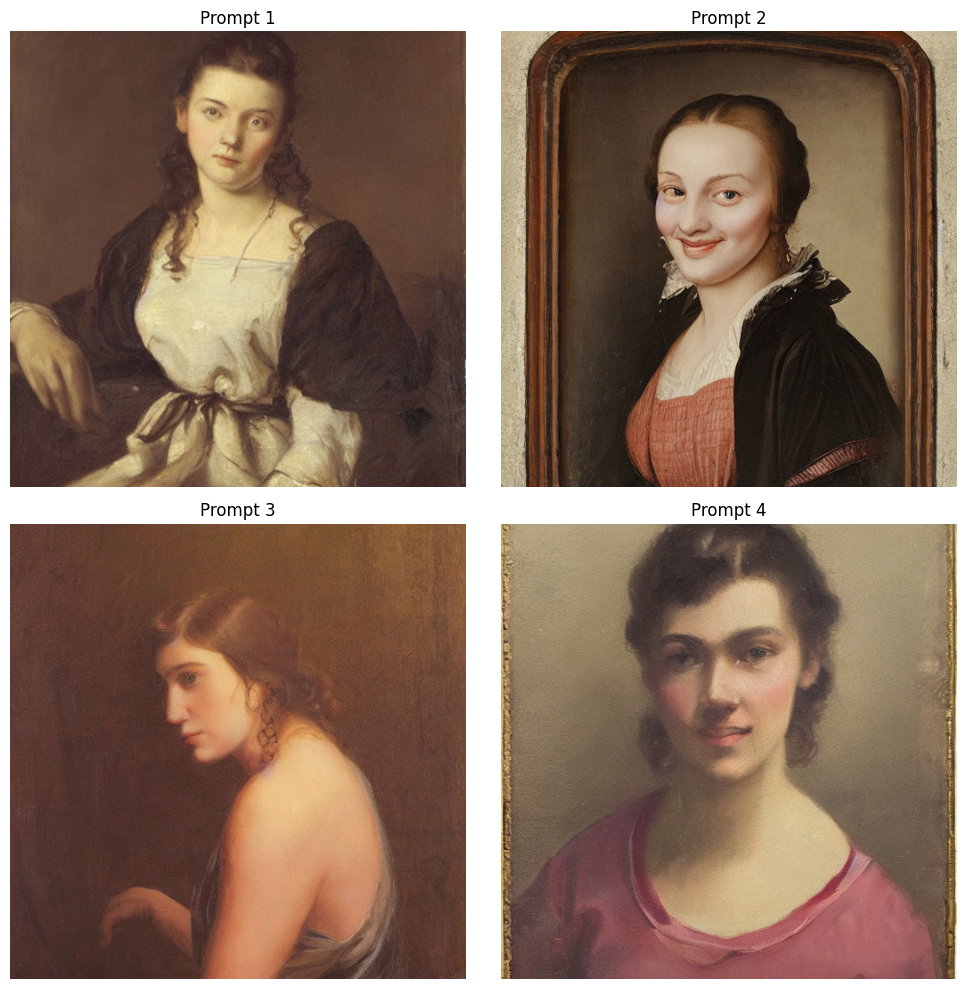

In [8]:
# prompt sensitivity

prompts = [
    "a portrait of a young woman",
    "a portrait of a young woman, smiling",
    "a portrait of a young woman, dramatic lighting",
    "a portrait of a young woman, soft studio lighting"
           ]

images = [pipe(p).images[0] for p in prompts]

# Display all images
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.flatten()
for i, img in enumerate(images):
  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(f'Prompt {i+1}')
plt.tight_layout()
plt.show()